# Exercise 10 -  Display the analytical solution
**Name:** Tristan Mitchell  
**Student Number:** MTCTRI001 

### AI Declaration
I provided Claude.ai with the exercise and asked it to explain what each code cell did so I could gain a better understanding of it. I also asked it how to insert code into a Markdown cell so that I could reference lines of code while answering the questions. 


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [2]:
# problem parameters
c=1         # Advection speed [m s-1]
dx=500      # X resolution [m]
dt=200      # time step [s]
t0=0.       # initial time
tmax=0.1    # duration of simulation [days]
xmax=10.0e3 # length of the basin [m]

# Grid definition
# time axis
NT = int(np.floor(tmax*86400/dt))+1  # number of steps (starts from 0)
# X axis (centred at 0)
x = np.arange(-xmax,xmax,dx)
IM = len(x)   # number of grid points
print('grid size : ',IM)
print('number of timesteps : ',NT)

grid size :  40
number of timesteps :  44


In [5]:
#%% Spatial shape of the temperature disturbance
def Gaussian(x):
    # This is a Gaussian (peak) function with the following params
    T0 = 15         # baseline temperature [degC]
    sigma = 3000.   # width at half amplitude [m]
    A = 5.          # amplitude [degC]
    Gaussian = T0+A*np.exp(-(x/sigma)**2)
    return Gaussian

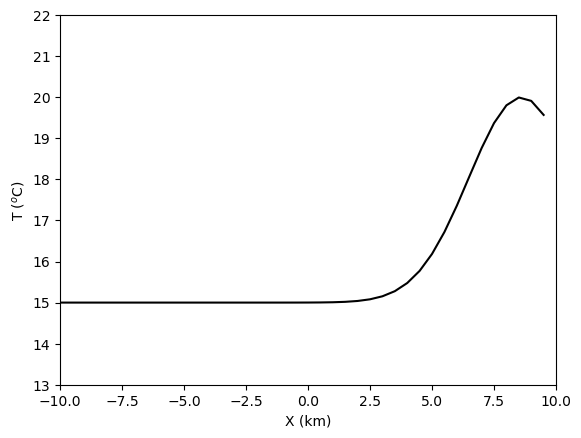

In [6]:
#%% plot an animation of the temperature disturbance
fig, ax = plt.subplots()
# set the axis limits and turn off autoscaling
plt.axis([-xmax/1000, xmax/1000, 13, 22])
plt.autoscale(False)
line, = ax.plot(x/1000., Gaussian(x),'k')
ax.set_xlabel('X (km)')
ax.set_ylabel('T ($^o$C)')

def animate(i):
    t = t0 + i*dt
    line.set_ydata(Gaussian(x-c*t))  # update the data.
    return line,

# create the animation (interval is in ms)
ani = animation.FuncAnimation(
    fig, animate, interval=200, blit=True, frames=NT, repeat=True)

HTML(ani.to_jshtml())

# Exercise 10 questions

Show what happens when:

1. you change the values of dx and c
2.  you increase or decrease the parameter σ

## Effect of changing dx
Increasing dx (X resolution [m]) from 500 m to 2000 m decreases the grid points, causing the temperature disturbance to appear blockier and less smooth. Although the animation moves at the same speed, the peak's spatial resolution becomes coarser. On the other hand, decreasing dx results in a smoother and more detailed curve.
## Effect of changing c
Increasing c (advection speed [m s-1]), such as from 1 to 5 m/s, accelerates the movement of the temperature disturbance across the basin length [m], resulting in the peak leaving in fewer time steps. On the other hand, decreasing c reduces the movement speed. Thus, c influences only how quickly the peak moves, not its shape.
## Effect of changing σ
Sigma controls the width of the Gaussian peak inside the function:

```python
Gaussian = T0+A*np.exp(-(x/sigma)**2)
```

Increasing sigma (e.g., from 1000 m to 3000 m) widens the peak and spreads the temperature disturbance more, while the peak height remains unchanged. On the other hand, decreasing sigma (e.g., to 300 m) narrows and concentrates the peak. If sigma is much smaller than dx, the peak becomes too narrow for the grid, causing a jagged look in the plot.
